# LSTM – 30‑Minute Waste Forecast

This notebook trains an LSTM neural network for each canteen section. The input is a sequence of the past 24 waste values (12 hours). We do not use any extra features—only past waste values.

We save the trained models and plots in the `deployment_models/` folder.

In [11]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from google.colab import drive

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

In [12]:
# Mount Google Drive and set the working directory
drive.mount('/content/drive', force_remount=True)
try:
    os.chdir('/content/drive/MyDrive/UAB/FDS/campus-waste-intelligence')
    print('Directory changed to project folder')
except OSError:
    print("Error: Could not change directory. Please check the path.")

Mounted at /content/drive
Directory changed to project folder


## Configuration

We set all the parameters for the data processing and the LSTM model. Changing these values later may require re‑training the models.

In [13]:
DATA_PATH   = 'data/food_waste_features.csv'
MODEL_DIR   = 'deployment_models'
MODEL_NAME  = 'LSTM'

FREQ        = '30min'
ALIGN_SECTIONS = 'union'      # 'common' drops missing, 'union' fills with 0
TRAIN_RATIO = 0.7
VAL_RATIO   = 0.1
TEST_RATIO  = 0.2
LOOKBACK    = 24               # number of past time steps used as input
LSTM_HIDDEN = 50
LSTM_LAYERS = 2
EPOCHS      = 50
BATCH_SIZE  = 16
LR          = 0.001
MIN_SAMPLES = 10

os.makedirs(MODEL_DIR, exist_ok=True)

print(f"Aggregation frequency: {FREQ}")
print(f"Model: {MODEL_NAME}")
print(f"Lookback: {LOOKBACK} periods")

Aggregation frequency: 30min
Model: LSTM
Lookback: 24 periods


## Load and Prepare Data

We read the waste data, resample it to 30‑minute intervals, and sum the waste per canteen section. Then we pivot the table so that each section becomes a separate column.

In [14]:
df = pd.read_csv(DATA_PATH, parse_dates=['time_bin'])
daily_section = (
    df.set_index('time_bin')
      .groupby([pd.Grouper(freq=FREQ), 'Canteen_Section'])['Waste_Weight_kg']
      .sum()
      .reset_index()
      .rename(columns={'Waste_Weight_kg': 'Total_Waste_kg'})
)

In [15]:
daily_wide = (
    daily_section
    .pivot(index='time_bin', columns='Canteen_Section', values='Total_Waste_kg')
    .sort_index()
)

### Align Sections

If we choose `'common'`, we drop rows where any section is missing. If we choose `'union'`, we fill missing values with zero (assuming no waste was produced).

In [16]:
if ALIGN_SECTIONS == 'common':
    daily_wide = daily_wide.dropna()
else:
    daily_wide = daily_wide.fillna(0)

sections = daily_wide.columns.tolist()
print(f"Sections: {sections}")

Sections: ['A', 'B', 'C', 'D']


## Split into Train, Validation, Test

We divide the time series chronologically. The first 70% is for training, next 10% for validation, and the last 20% for testing.

In [17]:
ref_index = daily_wide.index
n_total   = len(ref_index)
n_test = max(1, int(n_total * TEST_RATIO))
n_val  = max(1, int(n_total * VAL_RATIO))
n_train = n_total - n_val - n_test

train_indices = ref_index[:n_train]
val_indices   = ref_index[n_train:n_train + n_val]
test_indices  = ref_index[n_train + n_val:]

train_mask = ref_index.isin(train_indices)
val_mask   = ref_index.isin(val_indices)
test_mask  = ref_index.isin(test_indices)

print(f"Train: {len(train_indices)}, Val: {len(val_indices)}, Test: {len(test_indices)}")

Train: 48825, Val: 6975, Test: 13950


## LSTM Model Definition

We define a simple LSTM with a fully connected output layer. The model takes a sequence of waste values and predicts the next value.

In [18]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=LSTM_HIDDEN,
                 num_layers=LSTM_LAYERS, output_size=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])   # take only the last output
        return out.squeeze()

## Helper Functions

These functions help create sequences, compute evaluation metrics, and plot results.

In [19]:
def create_sequences(data, lookback):
    """Create input-output pairs where input is a window of past values."""
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])
    return np.array(X), np.array(y)

In [20]:
def compute_regression_metrics(y_true, y_pred):
    """Compute RMSE, MAE, MAPE, and R²."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() > 0 else np.nan
    r2 = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}

In [21]:
def plot_learning_curve(losses, section, save_path=None):
    """Plot training loss over epochs."""
    plt.figure(figsize=(8,4))
    plt.plot(losses, label='Training Loss')
    plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
    plt.title(f'LSTM Learning Curve - Section {section}')
    plt.legend(); plt.grid(True)
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

In [22]:
def plot_predictions(y_true, y_pred, dates, section, max_points=200, save_path=None):
    """Plot predicted vs actual waste."""
    if len(dates) > max_points:
        step = len(dates) // max_points
        idx = range(0, len(dates), step)
        dates = dates[idx]; y_true = y_true[idx]; y_pred = y_pred[idx]
    plt.figure(figsize=(12,5))
    plt.plot(dates, y_true, label='Actual', marker='o', markersize=3, linestyle='-', linewidth=1)
    plt.plot(dates, y_pred, label='Predicted', marker='x', markersize=3, linestyle='--', linewidth=1)
    plt.xlabel('Date'); plt.ylabel('Waste (kg)')
    plt.title(f'LSTM Predictions vs Actual - Section {section}')
    plt.legend(); plt.grid(True); plt.xticks(rotation=45); plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

## Train a Separate LSTM for Each Canteen Section

We loop through each section, build the sequences, train the model, and evaluate it on the test set. We also save the model and performance plots.

In [23]:
all_metrics = []


Training LSTM for section A

--- Performance ---
  RMSE: 1.3769
  MAE: 0.9916
  MAPE: 64.8584
  R2: -0.0001
Saved model to deployment_models/section_A_LSTM.joblib


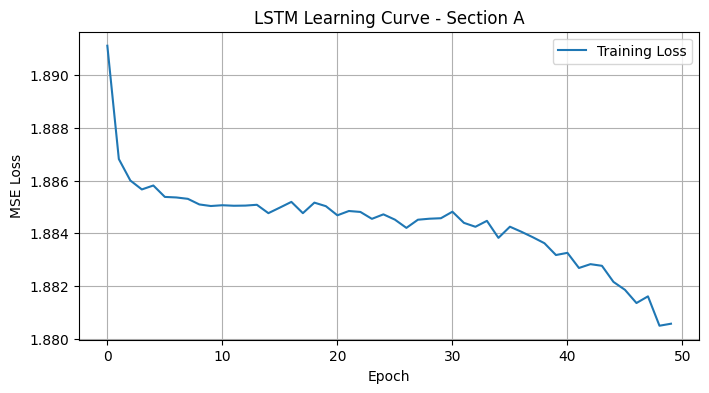

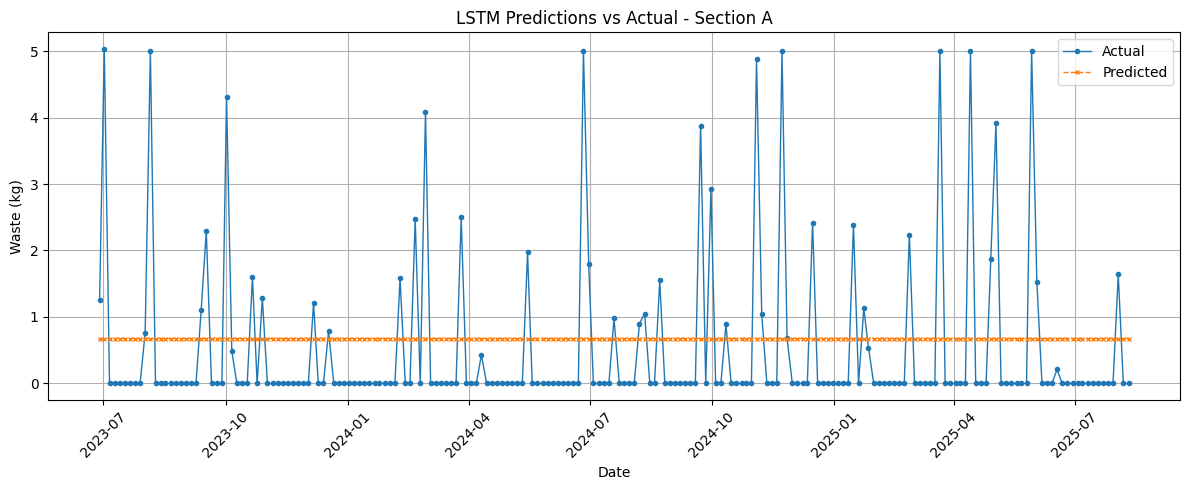


Training LSTM for section B

--- Performance ---
  RMSE: 1.3621
  MAE: 0.9696
  MAPE: 65.3260
  R2: -0.0004
Saved model to deployment_models/section_B_LSTM.joblib


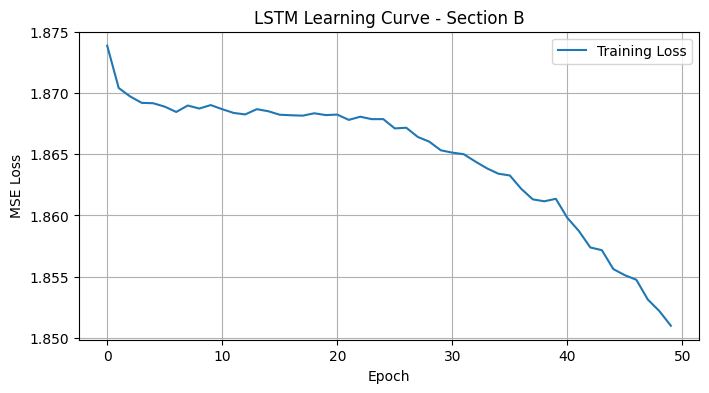

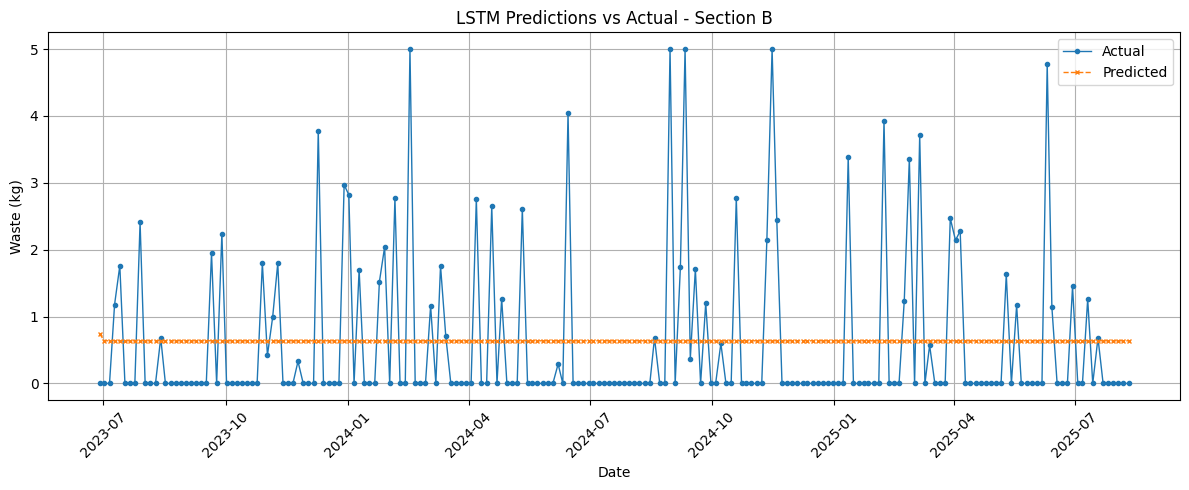


Training LSTM for section C

--- Performance ---
  RMSE: 1.3635
  MAE: 0.9445
  MAPE: 65.7743
  R2: -0.0023
Saved model to deployment_models/section_C_LSTM.joblib


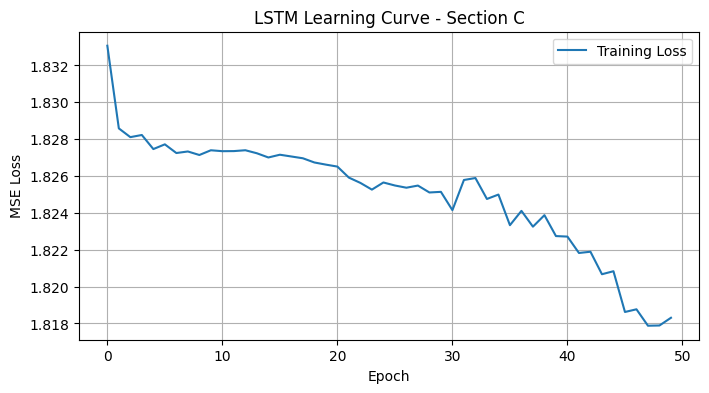

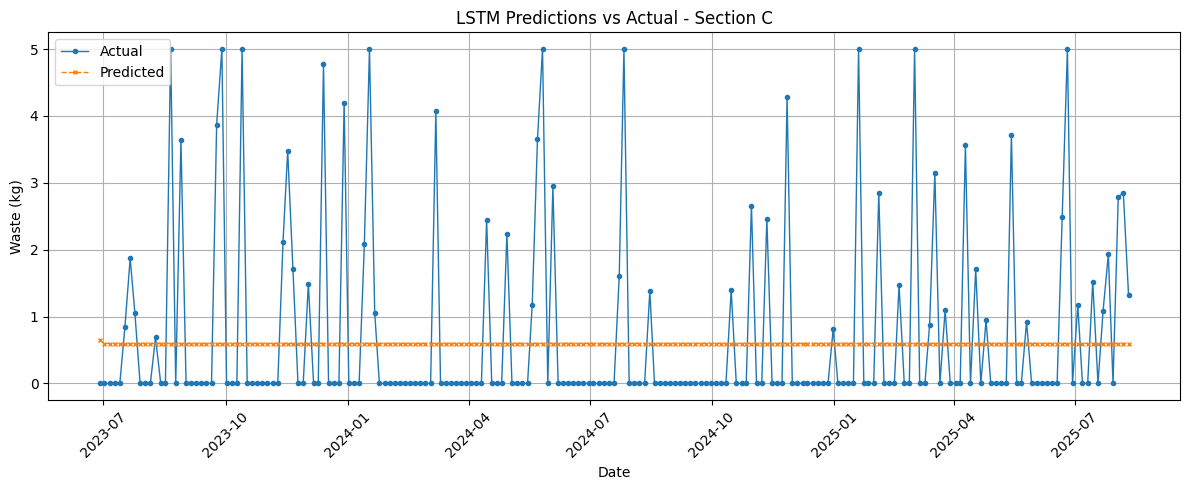


Training LSTM for section D

--- Performance ---
  RMSE: 1.3696
  MAE: 0.9976
  MAPE: 63.0024
  R2: -0.0003
Saved model to deployment_models/section_D_LSTM.joblib


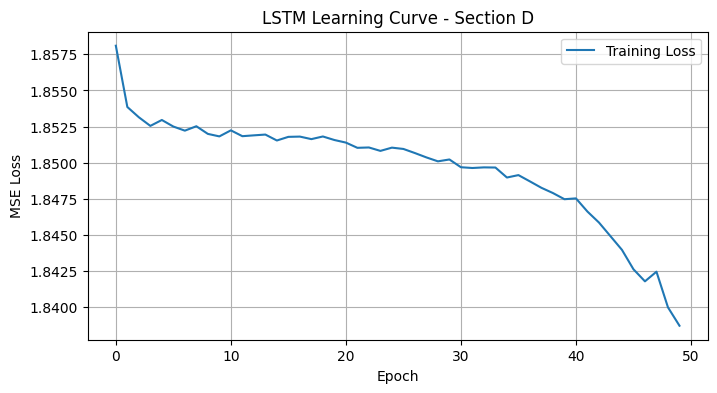

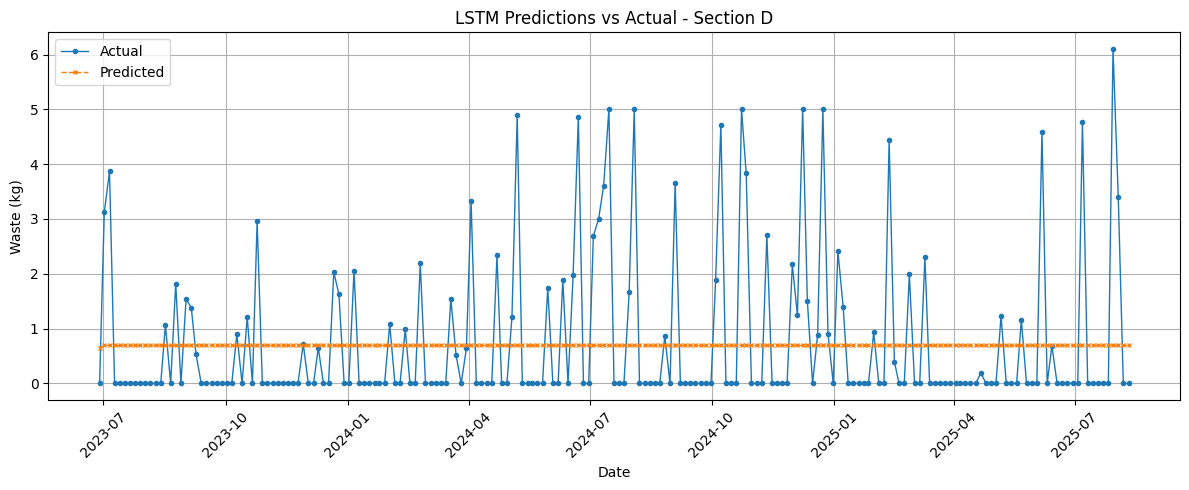

In [24]:
for sec in sections:
    print(f"\n{'='*60}\nTraining LSTM for section {sec}\n{'='*60}")

    y_series = daily_wide[sec]
    y_train = y_series[train_mask]
    y_val   = y_series[val_mask]
    y_test  = y_series[test_mask]

    if len(y_train) <= LOOKBACK:
        print(f"  Skipping section {sec} – not enough training data for lookback.")
        continue

    # Create sequences
    X_train_seq, y_train_seq = create_sequences(y_train.values, LOOKBACK)
    if len(y_val) > LOOKBACK:
        X_val_seq, y_val_seq = create_sequences(y_val.values, LOOKBACK)
    else:
        X_val_seq, y_val_seq = None, None

    # Convert to PyTorch tensors
    X_train_t = torch.tensor(X_train_seq, dtype=torch.float32).unsqueeze(-1)
    y_train_t = torch.tensor(y_train_seq, dtype=torch.float32)
    train_dataset = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

    if X_val_seq is not None:
        X_val_t = torch.tensor(X_val_seq, dtype=torch.float32).unsqueeze(-1)
        y_val_t = torch.tensor(y_val_seq, dtype=torch.float32)
        val_dataset = TensorDataset(X_val_t, y_val_t)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    else:
        val_loader = None

    # Model, loss, optimizer
    model = LSTMModel()
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)

    # Training loop
    train_losses = []
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(xb)
        epoch_loss /= len(train_dataset)
        train_losses.append(epoch_loss)

    # Recursive forecast for the test set
    last_train = y_train.values[-LOOKBACK:].reshape(1, LOOKBACK, 1)
    current_seq = torch.tensor(last_train, dtype=torch.float32)
    test_pred = []
    model.eval()
    with torch.no_grad():
        for _ in range(len(y_test)):
            pred = model(current_seq).item()
            test_pred.append(pred)
            new_val = torch.tensor([[[pred]]], dtype=torch.float32)
            current_seq = torch.cat([current_seq[:, 1:, :], new_val], dim=1)
    test_pred = np.array(test_pred)

    # Evaluate
    metrics = compute_regression_metrics(y_test.values, test_pred)
    print("\n--- Performance ---")
    for k,v in metrics.items(): print(f"  {k}: {v:.4f}")

    all_metrics.append({'Section': sec, 'Model': MODEL_NAME, **metrics})

    # Save model state and metadata
    param_count = sum(p.numel() for p in model.parameters())
    state_dict_path = f'{MODEL_DIR}/section_{sec}_{MODEL_NAME}.pth'
    torch.save(model.state_dict(), state_dict_path)
    file_size_kb = os.path.getsize(state_dict_path) / 1024

    # Measure inference latency
    sample_input = torch.randn(1, LOOKBACK, 1)
    t0 = time.perf_counter()
    for _ in range(100):
        _ = model(sample_input)
    latency_ms = (time.perf_counter() - t0) / 100 * 1000

    artifacts = {
        'section': sec,
        'model_name': MODEL_NAME,
        'lookback': LOOKBACK,
        'hidden_size': LSTM_HIDDEN,
        'num_layers': LSTM_LAYERS,
        'state_dict_path': f'section_{sec}_{MODEL_NAME}.pth',
        'param_count': param_count,
        'model_size_kb': file_size_kb,
        'inference_latency_ms': latency_ms,
        'train_date_range': [train_indices.min().isoformat(), train_indices.max().isoformat()],
        'val_date_range': [val_indices.min().isoformat(), val_indices.max().isoformat()],
        'test_date_range': [test_indices.min().isoformat(), test_indices.max().isoformat()]
    }
    save_path = f'{MODEL_DIR}/section_{sec}_{MODEL_NAME}.joblib'
    joblib.dump(artifacts, save_path)
    print(f"Saved model to {save_path}")

    # Create plots
    plot_learning_curve(train_losses, sec,
                        save_path=f'{MODEL_DIR}/section_{sec}_{MODEL_NAME}_learning_curve.png')
    plot_predictions(y_test.values, test_pred, test_indices, sec,
                     save_path=f'{MODEL_DIR}/section_{sec}_{MODEL_NAME}_predictions.png')

## Save Summary of Results

After training all sections, we collect the performance metrics into a CSV file for later comparison.

In [25]:
if all_metrics:
    summary_df = pd.DataFrame(all_metrics)
    summary_df.to_csv(f'{MODEL_DIR}/test_metrics_{MODEL_NAME}.csv', index=False)
    print("\nSummary saved.")
else:
    print("No metrics collected.")


Summary saved.
